## Libraries and Data Import

##### Import all necessary libraries

In [1]:
# Import pandas for working with data tables
import pandas as pd

# Import numpy for numerical calculations
import numpy as np

# Import matplotlib and seaborn for visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Import train_test_split for splitting the dataset
from sklearn.model_selection import train_test_split

# Import StandardScaler for scaling numeric features when needed
from sklearn.preprocessing import StandardScaler

# Import machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Import joblib for saving the model
import joblib

##### Load the dataset

In [2]:
# Load the modelling dataset
df = pd.read_csv("malaria_climate_population_model_dataset.csv")

# Show the first 5 rows
print(df.head())

  country_name  year  population_total  population_density  avg_temperature  \
0       Angola  2023          36749906           29.477746        25.885000   
1       Angola  2022          35635029           28.583484        25.544167   
2       Angola  2021          34532429           27.699069        26.310833   
3       Angola  2020          33451132           26.831741        26.374167   
4       Angola  2019          32375632           25.969064        26.341667   

   avg_relative_humidity  estimated_annual_precipitation  latitude  longitude  \
0              78.878333                          375.29  -8.81155     13.242   
1              78.264167                          289.40  -8.81155     13.242   
2              77.334167                          333.94  -8.81155     13.242   
3              77.599167                          298.67  -8.81155     13.242   
4              77.260833                          104.83  -8.81155     13.242   

   malaria_incidence  risk_level  
0  

##### Inspect the dataset

In [3]:
# Check the shape of the dataset
print("Shape of dataset:", df.shape)

# Check column names
print("\nColumns:\n", df.columns)

# Check data types
print("\nData types:\n", df.dtypes)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Check target distribution
print("\nTarget class distribution:\n", df["risk_level"].value_counts())

Shape of dataset: (1080, 11)

Columns:
 Index(['country_name', 'year', 'population_total', 'population_density',
       'avg_temperature', 'avg_relative_humidity',
       'estimated_annual_precipitation', 'latitude', 'longitude',
       'malaria_incidence', 'risk_level'],
      dtype='str')

Data types:
 country_name                          str
year                                int64
population_total                    int64
population_density                float64
avg_temperature                   float64
avg_relative_humidity             float64
estimated_annual_precipitation    float64
latitude                          float64
longitude                         float64
malaria_incidence                 float64
risk_level                          int64
dtype: object

Missing values:
 country_name                      0
year                              0
population_total                  0
population_density                0
avg_temperature                   0
avg_relative_humidit

## Feature Selection

In [4]:
# Define the features X
# Important: malaria_incidence is NOT included because it was used to create risk_level
X = df[
    [
        "year",
        "population_total",
        "population_density",
        "avg_temperature",
        "avg_relative_humidity",
        "estimated_annual_precipitation",
        "latitude",
        "longitude"
    ]
]

# Define the target y
y = df["risk_level"]

# View the features
print("Features:")
print(X.head())

# View the target
print("\nTarget:")
print(y.head())

# Check shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Features:
   year  population_total  population_density  avg_temperature  \
0  2023          36749906           29.477746        25.885000   
1  2022          35635029           28.583484        25.544167   
2  2021          34532429           27.699069        26.310833   
3  2020          33451132           26.831741        26.374167   
4  2019          32375632           25.969064        26.341667   

   avg_relative_humidity  estimated_annual_precipitation  latitude  longitude  
0              78.878333                          375.29  -8.81155     13.242  
1              78.264167                          289.40  -8.81155     13.242  
2              77.334167                          333.94  -8.81155     13.242  
3              77.599167                          298.67  -8.81155     13.242  
4              77.260833                          104.83  -8.81155     13.242  

Target:
0    1
1    1
2    1
3    1
4    1
Name: risk_level, dtype: int64

Shape of X: (1080, 8)
Shape of y: (10

##### Split the dataset

In [5]:
# Split the dataset into training and testing sets
# stratify=y helps keep the class balance in both training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Check class balance in y_train and y_test
print("\nTraining target distribution:\n", y_train.value_counts())
print("\nTesting target distribution:\n", y_test.value_counts())

X_train shape: (864, 8)
X_test shape: (216, 8)
y_train shape: (864,)
y_test shape: (216,)

Training target distribution:
 risk_level
1    432
0    432
Name: count, dtype: int64

Testing target distribution:
 risk_level
1    108
0    108
Name: count, dtype: int64


##### Feature Scaling

In [6]:
# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully.")

Feature scaling completed successfully.


## Model Training

In [7]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using the scaled training data
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [8]:
# Make predictions on the scaled test data
y_pred_logistic = logistic_model.predict(X_test_scaled)

# Show first 10 predictions
print("Predicted values:", y_pred_logistic[:10])

# Show first 10 actual values
print("Actual values:", y_test.values[:10])

Predicted values: [1 0 0 0 0 1 1 1 0 1]
Actual values: [1 0 0 0 0 0 1 1 0 1]


## Evaluate Model

In [9]:
# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

# Show classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.7453703703703703

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.74      0.74       108
           1       0.74      0.75      0.75       108

    accuracy                           0.75       216
   macro avg       0.75      0.75      0.75       216
weighted avg       0.75      0.75      0.75       216



##### Visualize Confusion Matrix

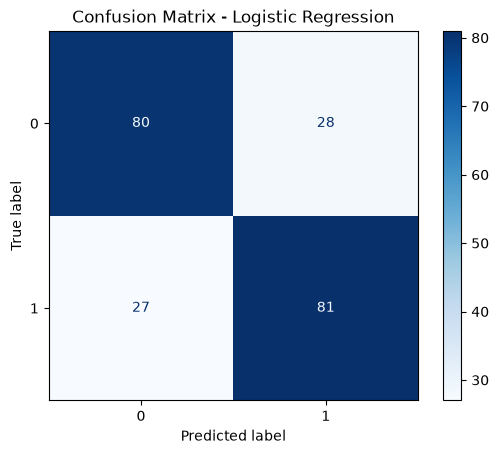

In [10]:
# Create confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Additional: Let's Train with DECISION TREE MODEL

In [11]:
# Create the Decision Tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
decision_tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [12]:
# Make predictions
y_pred_tree = decision_tree_model.predict(X_test)

In [13]:
# Evaluate accuracy
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.9259259259259259

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       108
           1       0.91      0.94      0.93       108

    accuracy                           0.93       216
   macro avg       0.93      0.93      0.93       216
weighted avg       0.93      0.93      0.93       216



##### Confusion Matrix for Decision Tree

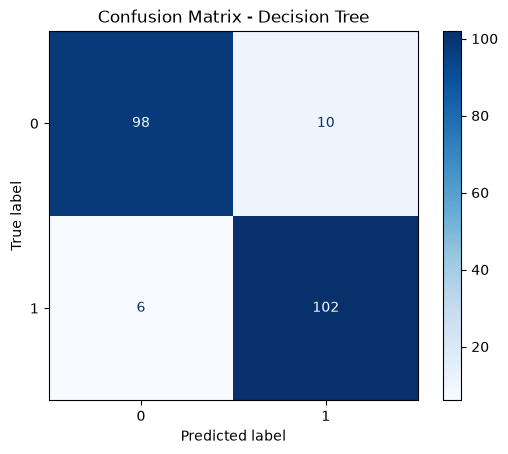

In [14]:
# Create confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Decision Tree")
plt.show()

## Additional: Let's Train with RANDOM FOREST MODEL

In [16]:
# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [17]:
# Make predictions
y_pred_forest = random_forest_model.predict(X_test)

In [18]:
# Evaluate accuracy
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:", forest_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_forest))

Random Forest Accuracy: 0.9537037037037037

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       108
           1       0.95      0.96      0.95       108

    accuracy                           0.95       216
   macro avg       0.95      0.95      0.95       216
weighted avg       0.95      0.95      0.95       216



##### Confusion Matrix for Random Forest

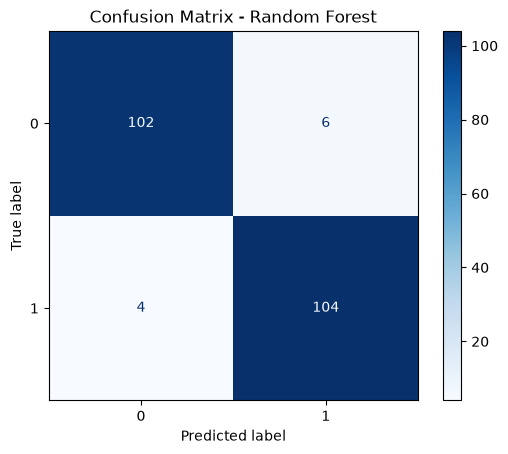

In [19]:
# Create confusion matrix
cm_forest = confusion_matrix(y_test, y_pred_forest)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_forest)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.show()

## Compare All Models

In [20]:
# Create a model comparison table
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.745370
1        Decision Tree  0.925926
2        Random Forest  0.953704


##### Visualize Model Comparison

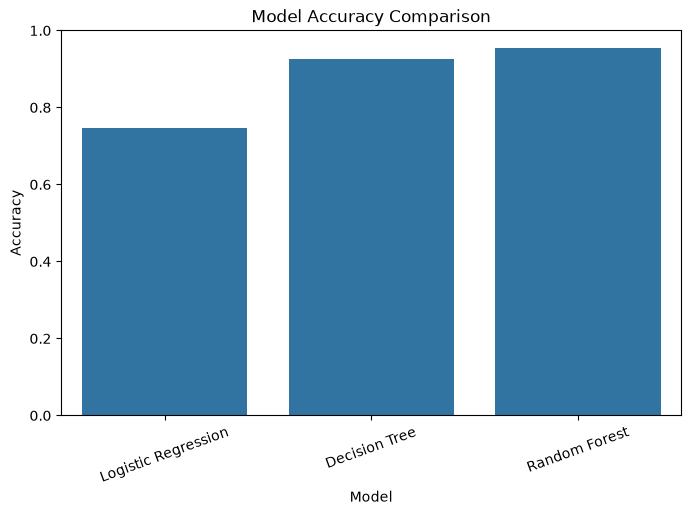

In [21]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

##### Check Feature Importance from Random Forest

In [22]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                          Feature  Importance
7                       longitude    0.190426
1                population_total    0.174082
6                        latitude    0.153812
3                 avg_temperature    0.142997
5  estimated_annual_precipitation    0.106034
2              population_density    0.089542
4           avg_relative_humidity    0.081531
0                            year    0.061576


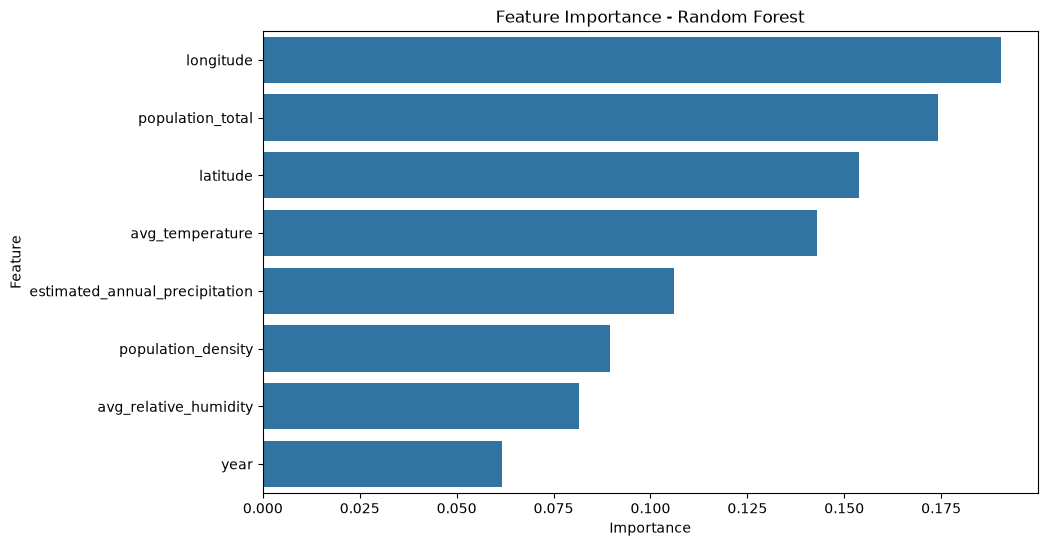

In [23]:
# Plot feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.show()

## Save the Best Model

In [24]:
# Save the Random Forest model
joblib.dump(random_forest_model, "malaria_risk_random_forest_model.pkl")

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [25]:
# Save feature importance as CSV
feature_importance.to_csv("malaria_risk_feature_importance.csv", index=False)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [26]:
# Save model comparison as CSV
model_comparison.to_csv("malaria_risk_model_comparison.csv", index=False)

print("Model comparison saved successfully.")

Model comparison saved successfully.
